# 📊 Exploratory Data Analysis (EDA 03) - Store Info Dataset (`Store_Info.csv`)
**Mục tiêu**: Phân tích thông tin master cửa hàng (`Store_Info.csv`), đánh giá toàn vẹn khóa chính (`Store_ID`), phân bổ loại hình cửa hàng (`Store_Type`), khu vực (`Region`) và đặc tả cấu trúc quản lý bán hàng (`RSM`/`AM`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập cấu hình hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1. Tải Dữ Liệu & Khai Thác Cấu Trúc (Schema Audit)

In [2]:
file_path = '../rawdata_test_ae/Store_Info.csv'
df_stores = pd.read_csv(file_path)

print(f"===> Kích thước danh mục cửa hàng Store Info: {df_stores.shape[0]} dòng, {df_stores.shape[1]} cột")
display(df_stores)

===> Kích thước danh mục cửa hàng Store Info: 15 dòng, 6 cột


,Store_ID,Store_Name,Region,RSM,AM,Store_Type
0,ST001,CH_HCM_Q1_0,Miền Nam,SangDT,TruongMN,D
1,ST002,CH_HCM_Q3_1,Miền Nam,SangDT,TruongMN,A
2,ST003,CH_HCM_GV_2,Miền Nam,SangDT,TruongMN,C
3,ST004,CH_HCM_TB_3,Miền Nam,SangDT,TruongMN,B
4,ST005,CH_BD_TDM_4,Miền Nam,SangDT,MinhDT,C
5,ST006,CH_HCM_Q1_5,Miền Nam,SangDT,MinhDT,D
6,ST007,CH_HCM_Q3_6,Miền Nam,SangDT,MinhDT,A
7,ST008,CH_HCM_GV_7,Miền Nam,SangDT,MinhDT,C
8,ST009,CH_HCM_TB_8,Miền Nam,DungTT,AnhNV,B
9,ST010,CH_BD_TDM_9,Miền Nam,DungTT,AnhNV,C


📌 **Nhận xét Cấu trúc Danh mục Cửa hàng (`Store_Info.csv`)**:
- Tập dữ liệu thô gồm **15 bản ghi danh mục cửa hàng** đại diện cho chuỗi bán lẻ CellphoneS.
- Các thuộc tính gồm 6 cột: `Store_ID` (Mã định danh cửa hàng), `Store_Name` (Tên cửa hàng), `Region` (Vùng miền kinh doanh), `RSM` (Giám đốc bán hàng vùng - Regional Sales Manager), `AM` (Quản lý khu vực - Area Manager) và `Store_Type` (Phân loại quy mô cửa hàng: A, B, C, D).

## 2. Kiểm Tra Trùng Lặp Khóa Chính & Dữ Liệu Khuyết Thiếu (Audit)

In [3]:
print("=== BẢNG KIỂM TRA TRÙNG LẶP & KHUYẾT THIẾU ===")
print(f"Số lượng Store_ID duy nhất (Unique): {df_stores['Store_ID'].nunique()} / Tổng số dòng: {len(df_stores)}")
print(f"Số lượng bản ghi trùng lặp 100% (Full Duplicates): {df_stores.duplicated().sum()} dòng")

null_df = pd.DataFrame({
    'Kiểu_Dữ_Liệu': df_stores.dtypes.astype(str),
    'Số_Lượng_Null': df_stores.isnull().sum(),
    'Tỷ_Lệ_Null (%)': (df_stores.isnull().sum() / len(df_stores)) * 100
})
display(null_df)

=== BẢNG KIỂM TRA TRÙNG LẶP & KHUYẾT THIẾU ===
Số lượng Store_ID duy nhất (Unique): 15 / Tổng số dòng: 15
Số lượng bản ghi trùng lặp 100% (Full Duplicates): 0 dòng


,Kiểu_Dữ_Liệu,Số_Lượng_Null,Tỷ_Lệ_Null (%)
Store_ID,str,0,0.0
Store_Name,str,0,0.0
Region,str,0,0.0
RSM,str,0,0.0
AM,str,0,0.0
Store_Type,str,0,0.0


📌 **Nhận xét & Kết luận Kiểm tra Khóa & Dữ liệu Khuyết thiếu**:
- **Độ toàn vẹn định danh**: Cột `Store_ID` chứa 15 giá trị duy nhất (Unique), đạt **0 bản ghi trùng lặp (0 Duplicates)**. Cột `Store_ID` hoàn toàn đủ điều kiện làm Khóa chính (Primary Key) cho bảng Dimension Cửa hàng (`dim_store`).
- **Dữ liệu khuyết thiếu**: Đạt **0 giá trị Null** trên tất cả 6 thuộc tính, đảm bảo chất lượng dữ liệu sạch 100% để nạp vào tầng Data Marts.

## 3. Phân Tích Phân Bổ Phân Loại Cửa Hàng (Store Type) & Vùng Kinh Doanh (Region)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2420\3573270477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_stores, x='Store_Type', palette='Set2', ax=axes[0], order=sorted(df_stores['Store_Type'].unique()))
C:\Users\Admin\AppData\Local\Temp\ipykernel_2420\3573270477.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_stores, x='Region', palette='Set1', ax=axes[1])


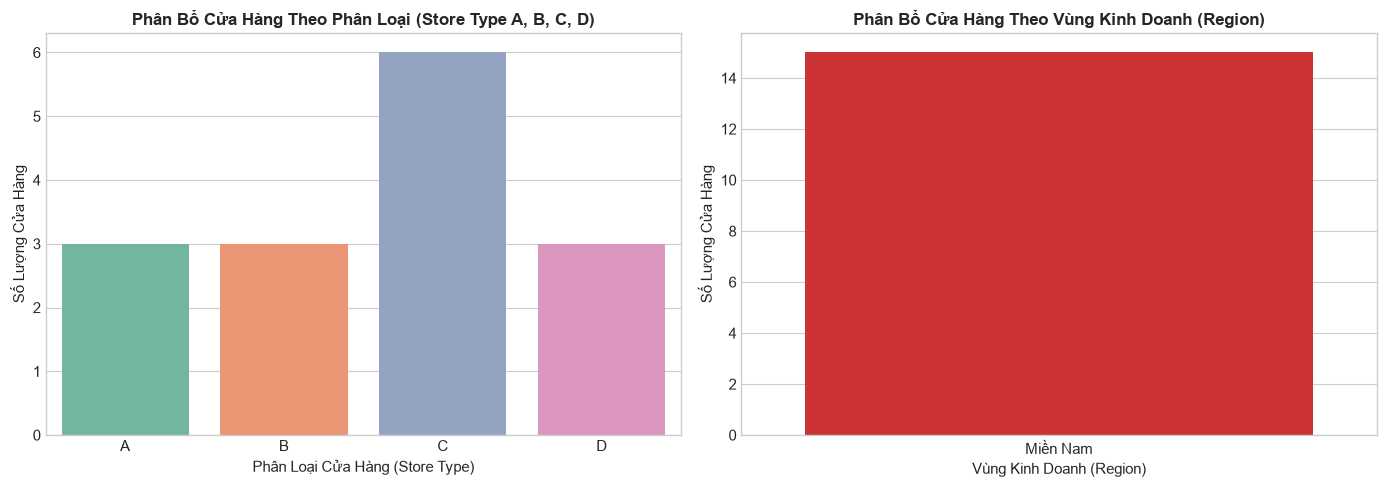

In [4]:
# Trực quan hóa phân bổ Store Type và Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_stores, x='Store_Type', palette='Set2', ax=axes[0], order=sorted(df_stores['Store_Type'].unique()))
axes[0].set_title('Phân Bổ Cửa Hàng Theo Phân Loại (Store Type A, B, C, D)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Phân Loại Cửa Hàng (Store Type)')
axes[0].set_ylabel('Số Lượng Cửa Hàng')

sns.countplot(data=df_stores, x='Region', palette='Set1', ax=axes[1])
axes[1].set_title('Phân Bổ Cửa Hàng Theo Vùng Kinh Doanh (Region)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vùng Kinh Doanh (Region)')
axes[1].set_ylabel('Số Lượng Cửa Hàng')

plt.tight_layout()
plt.show()

📌 **Nhận xét Phân bổ Phân loại Cửa hàng (`Store_Type`) & Vùng Kinh doanh (`Region`)**:
- **Phân bổ loại hình cửa hàng (`Store_Type`)**:
  - **Loại C**: Chiếm tỷ trọng cao nhất với **6 cửa hàng (40.0%)** – đại diện cho nhóm cửa hàng tiêu chuẩn (Standard Store) tại các khu vực đông dân cư.
  - **Loại A (Flagship Store)**: Gồm **3 cửa hàng (20.0%)** – cửa hàng quy mô lớn tại các trung tâm thương mại/quận trung tâm.
  - **Loại B (Key Store)**: Gồm **3 cửa hàng (20.0%)** – cửa hàng trọng điểm doanh thu.
  - **Loại D (Micro Store)**: Gồm **3 cửa hàng (20.0%)** – cửa hàng quy mô nhỏ vệ tinh.
- **Phân bổ vùng miền (`Region`)**: 100% cửa hàng thuộc khu vực **Miền Nam**, phân bố tại các khu vực đô thị TP. Hồ Chí Minh và Bình Dương.

## 4. Phân Tích Cấu Trúc Quản Lý Bán Hàng (RSM & AM Coverage)

In [5]:
rsm_am_summary = df_stores.groupby(['Region', 'RSM', 'AM']).agg(
    Store_Count=('Store_ID', 'count')
).reset_index()

print("=== BẢNG TỔNG HỢP CẤU TRÚC QUẢN LÝ BÁN HÀNG (RSM & AM) ===")
display(rsm_am_summary)

=== BẢNG TỔNG HỢP CẤU TRÚC QUẢN LÝ BÁN HÀNG (RSM & AM) ===


,Region,RSM,AM,Store_Count
0,Miền Nam,DungTT,AnhNV,4
1,Miền Nam,DungTT,VinhNH,3
2,Miền Nam,SangDT,MinhDT,4
3,Miền Nam,SangDT,TruongMN,4


📌 **Nhận xét Cấu trúc Quản lý Bán hàng (Sales Hierarchy) & Khuyến nghị Config Governance**:
- **Phân cấp quản lý (Hierarchy)**:
  - **2 Giám đốc vùng (RSM)**: `SangDT` (phụ trách 8 cửa hàng) và `DungTT` (phụ trách 7 cửa hàng).
  - **4 Quản lý khu vực (AM)**: `TruongMN` (4 cửa hàng), `MinhDT` (4 cửa hàng), `AnhNV` (4 cửa hàng), và `VinhNH` (3 cửa hàng).
- **Khuyến nghị Data Governance & Rule Engine YAML**:
  - Cần áp dụng **Config-Driven Architecture** thông qua tệp cấu hình YAML (`configs/shop_classifier.yaml`) để tự động mapping `Store_Type` (A, B, C, D) sang các cấp quản lý nghiệp vụ (`Flagship Store`, `Key Store`, `Standard Store`, `Micro Store`) và chỉ tiêu KPI bán hàng tương ứng mà không phải sửa mã nguồn Python hay SQL DDL.